<a href="https://colab.research.google.com/github/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/blob/main/notebooks/Pre_processamento_trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pré-processamento de dados

1. Importar bibliotecas

2. Carregar dados

3. Analisar a estrutura dos dados

4. Remover variáveis desnecessárias

5. Transformar dados

6. Remover dados omissos ou substituir por uma estatística

7. PCA

In [1]:
# importar bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

## Dados:

MEPS - Dados de seguro saúde dos EUA



In [2]:
# repositório dos dados
url = "https://raw.githubusercontent.com/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/refs/heads/main/data/healthinsurance.csv"
# carregamento dos dados
df = pd.read_csv(url)

In [3]:
df

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,39.0,male,49,28.3,NoDisease,1,1,Florence,54,1,0,FilmMaker,21082.2
14996,39.0,male,74,29.6,NoDisease,4,0,Miami,64,1,0,Student,7512.3
14997,20.0,male,62,33.3,NoDisease,0,0,Tampa,52,1,0,FashionDesigner,1391.5
14998,52.0,male,88,36.7,NoDisease,0,0,PanamaCity,70,1,0,Farmer,9144.6


### Pipeline de Pré-processamento Consolidada (Boas Práticas)

Esta seção consolida todas as etapas de pré-processamento que foram definidas, seguindo as melhores práticas para evitar _data leakage_ e garantir a consistência dos dados. Recomenda-se executar estas células e considerar o `X_train_pca` e `X_test_pca` resultantes como os conjuntos finais para modelagem.

As células de pré-processamento anteriores (como as que manipulavam `df` diretamente ou introduziam `NaN`s artificialmente) devem ser ignoradas ou removidas manualmente para evitar confusão.

In [4]:
# 1. Recarregar os dados brutos do healthinsurance.csv para um novo DataFrame
url = "https://raw.githubusercontent.com/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/refs/heads/main/data/healthinsurance.csv"
df_processed = pd.read_csv(url)
print("DataFrame 'healthinsurance.csv' recarregado para processamento.")

# 2. Limpeza inicial (no df_processed completo)
# Remover 'job_title' (conforme análise anterior de alta cardinalidade)
if 'job_title' in df_processed.columns:
    df_processed = df_processed.drop(columns=['job_title'])
    print("Coluna 'job_title' removida.")

# Preencher valores ausentes em 'age' e 'bmi' com a mediana
for col in ['age', 'bmi']:
    if df_processed[col].isnull().any():
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f"Valores ausentes na coluna '{col}' preenchidos com a mediana ({median_val}).")

print("\nVerificação de valores ausentes após limpeza inicial:")
df_processed.info()

DataFrame 'healthinsurance.csv' recarregado para processamento.
Coluna 'job_title' removida.
Valores ausentes na coluna 'age' preenchidos com a mediana (40.0).
Valores ausentes na coluna 'bmi' preenchidos com a mediana (29.4).

Verificação de valores ausentes após limpeza inicial:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  15000 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regu

/tmp/ipykernel_755/3748899603.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(median_val, inplace=True)


In [5]:
# 3. Separar as variáveis X (features) e y (target 'claim')
X = df_processed.drop('claim', axis=1)
y = df_processed['claim']
print("\nVariáveis X (features) e y (target 'claim') separadas.")

# 4. Dividir os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDados divididos em treinamento e teste:")
print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de y_test: {y_test.shape}")


Variáveis X (features) e y (target 'claim') separadas.

Dados divididos em treinamento e teste:
Formato de X_train: (12000, 11)
Formato de X_test: (3000, 11)
Formato de y_train: (12000,)
Formato de y_test: (3000,)


In [6]:
# 5. Aplicar escalonamento e One-Hot Encoding (apenas 'fit' em treino, 'transform' em treino e teste)

# Identificar colunas numéricas e categóricas para X_train
numeric_cols_minmax = ['age', 'bmi'] # MinMaxScaler
numeric_cols_standard = ['weight', 'bloodpressure'] # StandardScaler
categorical_cols = X_train.select_dtypes(include='object').columns.tolist() # One-Hot Encoding
# A coluna 'smoker' é int64 e binária, não sendo escalada ou OHE por padrão aqui, conforme mantido.

# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
X_train[numeric_cols_minmax] = minmax_scaler.fit_transform(X_train[numeric_cols_minmax])
X_test[numeric_cols_minmax] = minmax_scaler.transform(X_test[numeric_cols_minmax])
print("Colunas 'age' e 'bmi' escaladas com MinMaxScaler (fit em treino, transform em treino e teste).")

# Aplicar StandardScaler
standard_scaler = StandardScaler()
X_train[numeric_cols_standard] = standard_scaler.fit_transform(X_train[numeric_cols_standard])
X_test[numeric_cols_standard] = standard_scaler.transform(X_test[numeric_cols_standard])
print("Colunas 'weight' e 'bloodpressure' escaladas com StandardScaler (fit em treino, transform em treino e teste).")

# Aplicar One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Alinhar colunas de treino e teste após One-Hot Encoding para garantir que tenham as mesmas colunas
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols] # Garantir a mesma ordem de colunas

print("Variáveis categóricas transformadas com One-Hot Encoding (aplicado separadamente em treino e teste).")
print(f"\nFormato de X_train após transformações: {X_train.shape}")
print(f"Formato de X_test após transformações: {X_test.shape}")

Colunas 'age' e 'bmi' escaladas com MinMaxScaler (fit em treino, transform em treino e teste).
Colunas 'weight' e 'bloodpressure' escaladas com StandardScaler (fit em treino, transform em treino e teste).
Variáveis categóricas transformadas com One-Hot Encoding (aplicado separadamente em treino e teste).

Formato de X_train após transformações: (12000, 108)
Formato de X_test após transformações: (3000, 108)


In [7]:
# 6. Aplicar PCA (fit em treino, transform em treino e teste)

pca = PCA() # Inicializar PCA sem especificar número de componentes para analisar a variância
pca.fit(X_train) # Ajustar PCA apenas nos dados de treino

# Selecionar o número de componentes para explicar, por exemplo, 95% da variância
n_components_pca = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"\nSerão utilizados {n_components_pca} componentes para explicar 95% da variância no conjunto de treino.")

# Aplicar PCA com o número de componentes selecionado
pca_final = PCA(n_components=n_components_pca)
X_train_pca = pca_final.fit_transform(X_train) # Fit e transform em treino
X_test_pca = pca_final.transform(X_test)     # Apenas transform em teste

print("\nDados de treino após PCA (primeiras 5 linhas):")
display(pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(n_components_pca)]).head())
print("\nDados de teste após PCA (primeiras 5 linhas):")
display(pd.DataFrame(X_test_pca, columns=[f'PC_{i+1}' for i in range(n_components_pca)]).head())

print(f"Formato de X_train_pca: {X_train_pca.shape}")
print(f"Formato de X_test_pca: {X_test_pca.shape}")


Serão utilizados 67 componentes para explicar 95% da variância no conjunto de treino.

Dados de treino após PCA (primeiras 5 linhas):


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_58,PC_59,PC_60,PC_61,PC_62,PC_63,PC_64,PC_65,PC_66,PC_67
0,1.180777,-0.400653,0.793424,-0.660251,0.123511,-0.045301,0.253611,-0.013997,0.030463,-0.148756,...,0.003456,0.000023,0.002141,0.005643,0.002743,-0.000890,0.000424,-0.003463,0.000478,-0.003011
1,0.740506,0.904030,-0.252389,-0.295626,0.791670,-0.107642,-0.241832,0.537621,0.423783,0.064897,...,0.004143,-0.002949,0.006393,0.012969,-0.005236,-0.007426,0.002427,-0.007461,0.001627,-0.002839
2,2.058089,0.706865,0.652769,-0.600236,0.100261,-0.078896,0.251604,-0.246720,-0.014432,-0.055555,...,0.006916,-0.004325,0.013596,0.011829,-0.004437,-0.003423,-0.003805,-0.009335,0.000956,-0.008760
3,-0.767554,-0.659466,1.177274,-0.651265,0.165583,0.012045,0.308285,0.232788,0.050987,-0.136511,...,0.001286,-0.001427,0.007014,0.003706,0.002475,-0.000033,0.000861,-0.001162,-0.001818,-0.001828
4,1.577433,1.247840,-0.706575,-0.449120,-0.495589,-0.658899,-0.311030,-0.110010,-0.000583,-0.219223,...,0.026106,0.000559,0.011389,0.018177,-0.002619,-0.003519,-0.006139,-0.021802,-0.006005,-0.001995



Dados de teste após PCA (primeiras 5 linhas):


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_58,PC_59,PC_60,PC_61,PC_62,PC_63,PC_64,PC_65,PC_66,PC_67
0,-1.408191,0.943697,-0.437318,0.558890,-0.027300,0.009231,0.537256,0.340036,0.014088,0.060419,...,-0.093342,-0.008428,-0.056699,-0.010189,-0.028309,-0.042751,-0.023491,0.087216,0.058131,-0.006996
1,-1.546115,0.222646,-1.181282,-0.343270,-0.219969,0.764216,-0.220265,-0.371241,0.040944,-0.195898,...,0.000774,0.001491,0.009433,0.000864,0.000876,-0.000966,-0.002130,-0.000287,-0.002282,0.003776
2,-0.475877,2.366888,-0.207007,-0.333053,-0.200938,0.745735,-0.155673,-0.078101,-0.001105,0.099545,...,0.000434,-0.009385,-0.007638,0.011275,-0.002267,0.000737,0.003317,0.004630,-0.004235,0.000719
3,-1.123992,0.026107,0.216935,-0.498713,-0.165525,0.804530,-0.173319,0.297973,0.004825,-0.025749,...,-0.008954,0.003152,-0.007426,-0.003984,0.003389,0.001167,0.000195,0.007851,-0.004287,0.005288
4,2.322951,-0.697132,0.996272,0.266067,-0.060793,-0.072319,0.370993,-0.459633,-0.033968,-0.071069,...,-0.007175,0.006524,-0.008779,-0.014601,0.000430,0.001803,-0.001659,0.001598,0.003175,0.001209


Formato de X_train_pca: (12000, 67)
Formato de X_test_pca: (3000, 67)


In [8]:
df['age'].mean()
df[['age', 'bmi']].mean()

,0
age,39.547521
bmi,30.266413


In [9]:
df.loc[[0, 1, 10],['age', 'bmi', 'claim']]

,age,bmi,claim
0,60.0,24.3,13112.6
1,49.0,22.6,9567.0
10,51.0,33.0,44400.4


In [10]:
# df.head(3)
df.iloc[0:3,10:]

,regular_ex,job_title,claim
0,0,Actor,13112.6
1,1,Engineer,9567.0
2,1,Academician,32734.2


In [11]:
# primeiras 5 linhas
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [12]:
# informação da estrutura dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


In [13]:
type(1)

int

In [14]:
# criar lista com os nomes das variáveis a serem removidas
# nesta base, não foram identificadas variáveis que precisem ser removidas nesta etapa
var_remover = []

# usar método drop para remover
df = df.drop(columns=var_remover)

In [15]:
# visualizar novamente
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [16]:
# No conjunto de dados utilizado neste trabalho, não será removida
# nenhuma variável adicional nesta etapa.

# visualizar novamente
display(df.head())

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


### Análise de Variáveis Categóricas para Remoção

Vamos inspecionar as variáveis do tipo `object` para verificar sua cardinalidade (número de valores únicos) e suas frequências. Variáveis com muitos valores únicos podem ser consideradas para remoção ou para uma estratégia de tratamento específica (e.g., One-Hot Encoding ou Target Encoding), dependendo do contexto do problema.

In [17]:
# Identificar colunas do tipo 'object'
object_cols = df.select_dtypes(include='object').columns

print("Análise de variáveis categóricas (tipo 'object'):\n")

for col in object_cols:
    print(f"Variável: {col}")
    print(f"Número de valores únicos: {df[col].nunique()}")
    print(f"Valores e Contagens:\n{df[col].value_counts()}\n")
    print("-" * 50)

Análise de variáveis categóricas (tipo 'object'):

Variável: sex
Número de valores únicos: 2
Valores e Contagens:
sex
female    7652
male      7348
Name: count, dtype: int64

--------------------------------------------------
Variável: hereditary_diseases
Número de valores únicos: 10
Valores e Contagens:
hereditary_diseases
NoDisease       13998
Diabetes          148
Alzheimer         144
Obesity           136
EyeDisease        123
Cancer            109
Arthritis          96
HeartDisease       93
Epilepsy           84
High BP            69
Name: count, dtype: int64

--------------------------------------------------
Variável: city
Número de valores únicos: 91
Valores e Contagens:
city
Nashville     302
NewOrleans    302
Charleston    298
Brimingham    298
Memphis       297
             ... 
Warwick        69
Syracuse       69
Trenton        69
York           69
Baltimore      69
Name: count, Length: 91, dtype: int64

--------------------------------------------------
Variável: job_titl

### Análise das variáveis categóricas

A análise identificou quatro variáveis categóricas do tipo `object`: `sex`, `hereditary_diseases`, `city` e `job_title`, com 2, 10, 91 e 35 valores únicos, respectivamente.

As variáveis `city` e `job_title` apresentam maior cardinalidade e, conforme a abordagem apresentada em aula, podem ser consideradas para remoção ou para um tratamento específico nas etapas posteriores de modelagem. A variável `hereditary_diseases`, embora apresente 10 categorias, também deverá ser observada quanto à sua forma de utilização no modelo.

Neste momento, optou-se por manter essas variáveis para que sua utilização seja avaliada nas etapas seguintes do pré-processamento e da modelagem.

In [18]:
# Reestruturando o código de remoção de variáveis
# Nesta etapa, optou-se por não remover variáveis categóricas apenas com base na cardinalidade
var_remover_manual = []

# Filtrar a lista para incluir apenas as colunas que realmente existem no DataFrame
columns_to_drop = [col for col in var_remover_manual if col in df.columns]

# Usar método drop para remover apenas as colunas existentes
if columns_to_drop:
    print(f"Removendo as seguintes colunas: {', '.join(columns_to_drop)}")
    df = df.drop(columns=columns_to_drop)
else:
    print("Nenhuma das colunas especificadas para remover foi encontrada no DataFrame ou a lista estava vazia.")

# Exibir as primeiras linhas do DataFrame após a remoção (para verificar)
display(df.head())

Nenhuma das colunas especificadas para remover foi encontrada no DataFrame ou a lista estava vazia.


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


### Tratamento de Valores Ausentes (NaN)

A análise inicial identificou valores ausentes nas variáveis `age` e `bmi`.
Para o tratamento desses valores, será utilizada a mediana, conforme o procedimento adotado no código de pré-processamento apresentado pelo professor. A mediana constitui uma das medidas que podem ser utilizadas para imputação de dados ausentes e apresenta maior robustez à presença de valores extremos.

In [19]:
# Preencher valores ausentes em 'age' e 'bmi' com a mediana
for col in ['age', 'bmi']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Valores ausentes na coluna '{col}' preenchidos com a mediana ({median_val}).")

# Verificar novamente se há valores ausentes
print("\nVerificação final de valores ausentes:")
df.info()

Valores ausentes na coluna 'age' preenchidos com a mediana (40.0).
Valores ausentes na coluna 'bmi' preenchidos com a mediana (29.4).

Verificação final de valores ausentes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  15000 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim       

### Tratamento dos valores ausentes

Foram identificados valores ausentes nas variáveis `age` e `bmi`. Conforme o procedimento de pré-processamento apresentado em aula, esses valores foram substituídos pelas respectivas medianas, correspondentes a **40,0 para `age`** e **29,4 para `bmi`**.

A implementação original foi ajustada para evitar o `FutureWarning` relacionado ao uso de `inplace=True` em atribuições encadeadas (*chained assignment*), mantendo-se inalterado o procedimento de imputação pela mediana.

Após o tratamento, todas as 13 variáveis passaram a apresentar 15.000 valores não nulos.

### Preparação dos dados para aplicação do PCA

Para adequar o procedimento apresentado em aula ao problema deste trabalho, a variável `claim` será mantida como variável resposta e, portanto, não será utilizada na construção dos componentes principais.

A variável `job_title`, mantida na etapa anterior, também será considerada entre as variáveis categóricas e transformada por One-Hot Encoding juntamente com as demais variáveis dessa natureza.

As demais etapas de tratamento e transformação seguem o procedimento de pré-processamento apresentado em aula.

### Transformação de Dados

Agora que os valores ausentes foram tratados, podemos prosseguir com a transformação de dados (Passo 5 do plano). Vamos aplicar a escala `MinMaxScaler` para `age` e `bmi` e o `StandardScaler` para `weight`, que são variáveis numéricas contínuas. Para as variáveis categóricas, vamos aplicar One-Hot Encoding.

In [20]:
# Inicializar scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# Aplicar MinMaxScaler para 'age' e 'bmi'
df[['age', 'bmi']] = minmax_scaler.fit_transform(df[['age', 'bmi']])
print("Colunas 'age' e 'bmi' escaladas com MinMaxScaler.")

# Aplicar StandardScaler para 'weight' e 'bloodpressure'
df[['weight', 'bloodpressure']] = standard_scaler.fit_transform(
    df[['weight', 'bloodpressure']]
)
print("Colunas 'weight' e 'bloodpressure' escaladas com StandardScaler.")

# Aplicar One-Hot Encoding para as variáveis categóricas
categorical_cols = ['sex', 'hereditary_diseases', 'city', 'job_title']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Variáveis categóricas transformadas com One-Hot Encoding.")

# Separar variável resposta das variáveis preditoras
y = df['claim']
X = df.drop(columns='claim')

print("\nDimensão das variáveis preditoras (X):", X.shape)
print("Dimensão da variável resposta (y):", y.shape)

Colunas 'age' e 'bmi' escaladas com MinMaxScaler.
Colunas 'weight' e 'bloodpressure' escaladas com StandardScaler.
Variáveis categóricas transformadas com One-Hot Encoding.

Dimensão das variáveis preditoras (X): (15000, 142)
Dimensão da variável resposta (y): (15000,)


In [21]:
X[['age', 'weight', 'bmi', 'no_of_dependents',
   'smoker', 'bloodpressure', 'diabetes', 'regular_ex']].describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000,15000.000000
mean,0.468684,1.743198e-16,0.383051,1.129733,0.198133,2.160050e-16,0.777000,0.224133
std,0.300650,1.000033e+00,0.159795,1.228469,0.398606,1.000033e+00,0.416272,0.417024
min,0.000000,-2.255932e+00,0.000000,0.000000,0.000000,-3.535410e+00,0.000000,0.000000
25%,0.195652,-7.962353e-01,0.266846,0.000000,0.000000,-2.394770e-01,1.000000,0.000000
50%,0.478261,-1.393718e-01,0.361186,1.000000,0.000000,1.210157e-01,1.000000,0.000000
75%,0.717391,8.094309e-01,0.487871,2.000000,0.000000,5.845063e-01,1.000000,0.000000
max,1.000000,2.196143e+00,1.000000,5.000000,1.000000,2.747463e+00,1.000000,1.000000


### Resultado da transformação dos dados

Após o tratamento dos valores ausentes, as variáveis `age` e `bmi` foram transformadas utilizando o `MinMaxScaler`, enquanto `weight` e `bloodpressure` foram padronizadas por meio do `StandardScaler`.

A inclusão de `bloodpressure` na padronização foi necessária devido à diferença de escala observada em relação às demais variáveis, evitando que sua maior variabilidade influenciasse de forma desproporcional a aplicação do PCA.

As variáveis categóricas `sex`, `hereditary_diseases`, `city` e `job_title` foram transformadas por One-Hot Encoding. A variável `job_title` foi mantida para que sua contribuição possa ser avaliada posteriormente na modelagem.

A variável `claim` foi mantida em sua escala original e separada como variável resposta (`y`), não sendo incluída entre as variáveis utilizadas no PCA. Após as transformações, o conjunto de variáveis preditoras (`X`) passou a apresentar 15.000 observações e 142 colunas.

### Aplicação de PCA

Agora que o DataFrame está limpo e transformado, podemos aplicar a Análise de Componentes Principais (PCA) para reduzir a dimensionalidade. Vamos começar visualizando a variância explicada por cada componente e acumulada para decidir quantos componentes usar.

### Aplicação de PCA

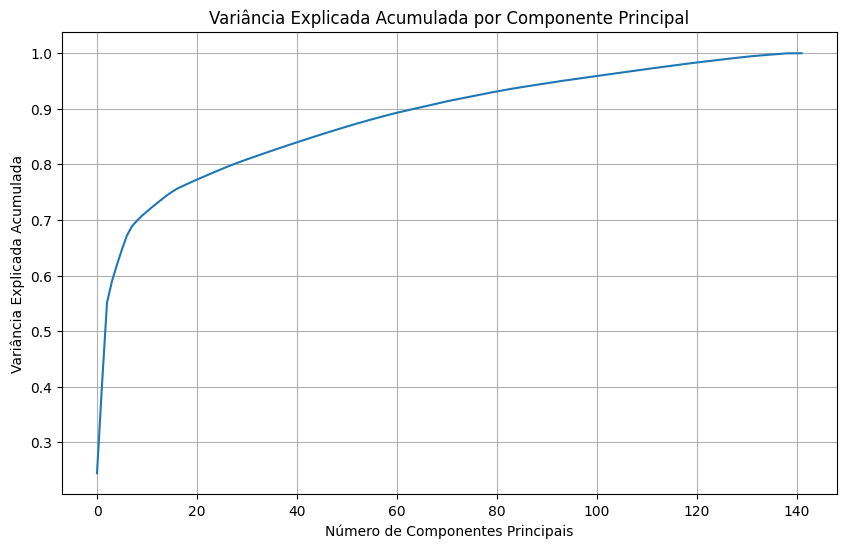

Variância explicada por cada componente:
[2.44227105e-01 1.58953081e-01 1.48058926e-01 3.85330887e-02
 2.98414341e-02 2.74203132e-02 2.51926320e-02 1.63789789e-02
 1.00087919e-02 8.92154468e-03 7.71626453e-03 7.62004441e-03
 7.35100991e-03 7.09276668e-03 6.96171376e-03 6.30052684e-03
 5.56762772e-03 4.29142194e-03 4.15260942e-03 4.05114300e-03
 3.95791724e-03 3.90536602e-03 3.88572803e-03 3.83755934e-03
 3.80410612e-03 3.77922676e-03 3.68052964e-03 3.52704964e-03
 3.42890084e-03 3.33536822e-03 3.18801319e-03 3.17747046e-03
 3.15321462e-03 3.12795051e-03 3.09905911e-03 3.07929025e-03
 3.05683262e-03 3.02894052e-03 3.01828123e-03 2.97507509e-03
 2.96358265e-03 2.95538121e-03 2.91740761e-03 2.90573193e-03
 2.88451001e-03 2.86344885e-03 2.84307904e-03 2.80790228e-03
 2.80291373e-03 2.74200061e-03 2.69407333e-03 2.67045409e-03
 2.62904186e-03 2.59391992e-03 2.57382984e-03 2.47173673e-03
 2.43823061e-03 2.42514453e-03 2.40900481e-03 2.33875245e-03
 2.20091099e-03 2.08226084e-03 2.07384120e-0

In [22]:
from numpy.ma.core import cumsum
# Inicializar e ajustar o PCA somente às variáveis preditoras
pca = PCA()
pca.fit(X)

# Visualizar a variância explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Variância Explicada Acumulada por Componente Principal')
plt.grid(True)
plt.show()

# Exibir a variância explicada por cada componente e acumulada
print("Variância explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("\nVariância explicada acumulada:")
print(np.cumsum(pca.explained_variance_ratio_))

### Escolha do número de componentes principais

A partir do gráfico e dos valores de variância acumulada, podemos escolher o número de componentes que explicam uma proporção satisfatória da variância total (por exemplo, 95% ou 99%).

Para continuar, vamos considerar a retenção de 95% da variância, conforme o procedimento apresentado em aula.

No conjunto de dados utilizado neste trabalho, são necessários **94 componentes principais** para explicar aproximadamente **95% da variância acumulada**.

In [23]:
# Selecionar o número de componentes para explicar 95% da variância
n_components = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Serão utilizados {n_components} componentes para explicar 95% da variância.")

# Aplicar PCA com o número de componentes selecionado
pca_final = PCA(n_components=n_components)
df_pca = pca_final.fit_transform(df)

# Criar um novo DataFrame com os componentes principais
df_pca_final = pd.DataFrame(data=df_pca, columns=[f'PC_{i+1}' for i in range(n_components)])

print("\nDataFrame após PCA:")
display(df_pca_final.head())
print("Dimensões do DataFrame PCA:", df_pca_final.shape)

Serão utilizados 94 componentes para explicar 95% da variância.

DataFrame após PCA:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_85,PC_86,PC_87,PC_88,PC_89,PC_90,PC_91,PC_92,PC_93,PC_94
0,-288.837626,-0.119636,0.103616,0.146761,0.511995,-0.588907,-0.458977,0.602341,0.104637,-0.108666,...,-0.303595,0.095539,-0.055815,-0.003324,-0.005921,0.000362,-0.023504,0.017961,-0.023944,-0.014888
1,-3834.437620,0.130206,0.070781,0.877375,-0.529484,0.801651,-0.242532,0.037570,0.068205,-0.058264,...,-0.239468,0.105169,0.070079,-0.002240,0.018631,0.017025,-0.002687,0.005687,-0.016553,-0.017171
2,19332.762406,0.643834,1.101164,0.061134,-0.417473,0.680768,-0.409629,-0.569214,-0.278500,-0.193176,...,-0.216553,0.081825,0.058030,0.012210,-0.009476,0.015358,-0.028141,0.047783,-0.019004,-0.059069
3,35116.162380,-0.657546,0.611243,-0.750024,-0.532590,-0.054430,0.131305,0.353421,0.124188,0.000143,...,-0.277696,0.090908,-0.099772,-0.002518,-0.009876,-0.007141,-0.013593,-0.003278,-0.014967,0.020633
4,-11669.737638,-1.299751,1.029136,-0.275762,-0.371842,-0.050840,0.307802,-0.159074,-0.629192,0.731609,...,0.130921,-0.130116,-0.102666,-0.061683,-0.035565,-0.133580,0.758358,-0.280349,-0.426423,-0.135340


Dimensões do DataFrame PCA: (15000, 94)


### Preparação de Dados para Modelagem: Divisão Treino/Teste e Aplicação de Transformações (Boas Práticas)

Conforme as observações anteriores, é crucial aplicar as transformações (escalonamento, One-Hot Encoding, PCA) separadamente nos conjuntos de treino e teste para evitar *data leakage*. O `fit` deve ser feito apenas no conjunto de treino, e o `transform` em ambos.

Vamos reiniciar o processo de pré-processamento seguindo esta metodologia.

In [24]:
# 1. Recarregar os dados brutos do healthinsurance.csv
url = "https://raw.githubusercontent.com/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/refs/heads/main/data/healthinsurance.csv"
df_raw = pd.read_csv(url)
print("DataFrame 'healthinsurance.csv' recarregado para pré-processamento.")

# 2. Limpeza inicial (no df_raw completo)
# Remover 'job_title'
if 'job_title' in df_raw.columns:
    df_raw = df_raw.drop(columns=['job_title'])
    print("Coluna 'job_title' removida.")

# Preencher valores ausentes em 'age' e 'bmi' com a mediana
for col in ['age', 'bmi']:
    if df_raw[col].isnull().any():
        median_val = df_raw[col].median()
        df_raw[col].fillna(median_val, inplace=True)
        print(f"Valores ausentes na coluna '{col}' preenchidos com a mediana ({median_val}).")

print("\nVerificação de valores ausentes após limpeza inicial:")
df_raw.info()

DataFrame 'healthinsurance.csv' recarregado para pré-processamento.
Coluna 'job_title' removida.
Valores ausentes na coluna 'age' preenchidos com a mediana (40.0).
Valores ausentes na coluna 'bmi' preenchidos com a mediana (29.4).

Verificação de valores ausentes após limpeza inicial:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  15000 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  

/tmp/ipykernel_755/202147703.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_raw[col].fillna(median_val, inplace=True)


In [25]:
# 3. Separar as variáveis X (features) e y (target 'claim')
X = df_raw.drop('claim', axis=1)
y = df_raw['claim']
print("\nVariáveis X (features) e y (target 'claim') separadas.")

# 4. Dividir os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDados divididos em treinamento e teste:")
print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de y_test: {y_test.shape}")


Variáveis X (features) e y (target 'claim') separadas.

Dados divididos em treinamento e teste:
Formato de X_train: (12000, 11)
Formato de X_test: (3000, 11)
Formato de y_train: (12000,)
Formato de y_test: (3000,)


In [26]:
# 5. Aplicar escalonamento e One-Hot Encoding

# Identificar colunas numéricas e categóricas para X_train
numeric_cols_minmax = ['age', 'bmi'] # MinMaxScaler
numeric_cols_standard = ['weight', 'bloodpressure'] # StandardScaler
categorical_cols = X_train.select_dtypes(include='object').columns.tolist() # One-Hot Encoding

# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
X_train[numeric_cols_minmax] = minmax_scaler.fit_transform(X_train[numeric_cols_minmax])
X_test[numeric_cols_minmax] = minmax_scaler.transform(X_test[numeric_cols_minmax])
print("Colunas 'age' e 'bmi' escaladas com MinMaxScaler (fit em treino, transform em treino e teste).")

# Aplicar StandardScaler
standard_scaler = StandardScaler()
X_train[numeric_cols_standard] = standard_scaler.fit_transform(X_train[numeric_cols_standard])
X_test[numeric_cols_standard] = standard_scaler.transform(X_test[numeric_cols_standard])
print("Colunas 'weight' e 'bloodpressure' escaladas com StandardScaler (fit em treino, transform em treino e teste).")

# Aplicar One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Alinhar colunas de treino e teste após One-Hot Encoding para garantir que tenham as mesmas colunas
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols] # Garantir a mesma ordem de colunas

print("Variáveis categóricas transformadas com One-Hot Encoding (aplicado separadamente em treino e teste).")
print(f"\nFormato de X_train após transformações: {X_train.shape}")
print(f"Formato de X_test após transformações: {X_test.shape}")

Colunas 'age' e 'bmi' escaladas com MinMaxScaler (fit em treino, transform em treino e teste).
Colunas 'weight' e 'bloodpressure' escaladas com StandardScaler (fit em treino, transform em treino e teste).
Variáveis categóricas transformadas com One-Hot Encoding (aplicado separadamente em treino e teste).

Formato de X_train após transformações: (12000, 108)
Formato de X_test após transformações: (3000, 108)


### Aplicação de PCA (fit em treino, transform em treino e teste)

Agora aplicaremos o PCA, ajustando-o (fit) apenas no conjunto de treino e transformando ambos os conjuntos.

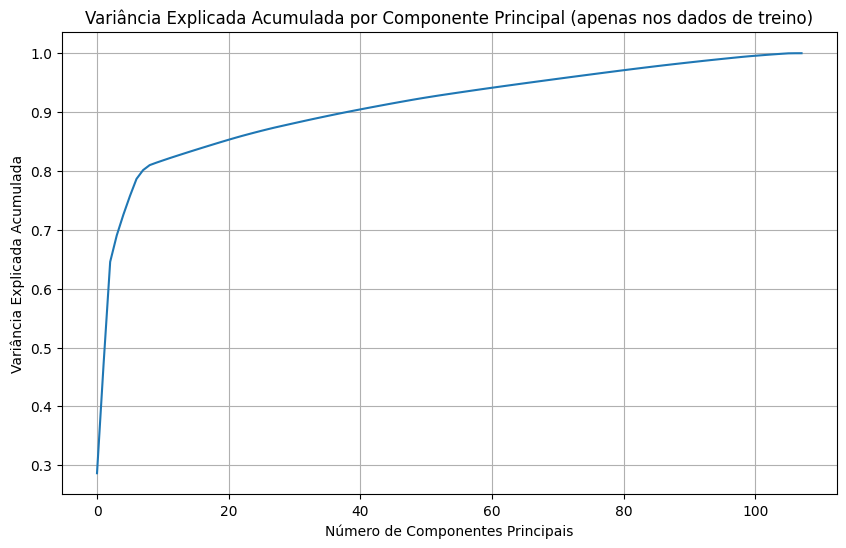

Serão utilizados 67 componentes para explicar 95% da variância no conjunto de treino.

Dados de treino após PCA:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_58,PC_59,PC_60,PC_61,PC_62,PC_63,PC_64,PC_65,PC_66,PC_67
0,1.180777,-0.400653,0.793424,-0.660251,0.123511,-0.045301,0.253611,-0.013997,0.030463,-0.148756,...,0.003456,0.000023,0.002141,0.005643,0.002743,-0.000890,0.000424,-0.003463,0.000478,-0.003011
1,0.740506,0.904030,-0.252389,-0.295626,0.791670,-0.107642,-0.241832,0.537621,0.423783,0.064897,...,0.004143,-0.002949,0.006393,0.012969,-0.005236,-0.007426,0.002427,-0.007461,0.001627,-0.002839
2,2.058089,0.706865,0.652769,-0.600236,0.100261,-0.078896,0.251604,-0.246720,-0.014432,-0.055555,...,0.006916,-0.004325,0.013596,0.011829,-0.004437,-0.003423,-0.003805,-0.009335,0.000956,-0.008760
3,-0.767554,-0.659466,1.177274,-0.651265,0.165583,0.012045,0.308285,0.232788,0.050987,-0.136511,...,0.001286,-0.001427,0.007014,0.003706,0.002475,-0.000033,0.000861,-0.001162,-0.001818,-0.001828
4,1.577433,1.247840,-0.706575,-0.449120,-0.495589,-0.658899,-0.311030,-0.110010,-0.000583,-0.219223,...,0.026106,0.000559,0.011389,0.018177,-0.002619,-0.003519,-0.006139,-0.021802,-0.006005,-0.001995



Dados de teste após PCA:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_58,PC_59,PC_60,PC_61,PC_62,PC_63,PC_64,PC_65,PC_66,PC_67
0,-1.408191,0.943697,-0.437318,0.558890,-0.027300,0.009231,0.537256,0.340036,0.014088,0.060419,...,-0.093342,-0.008428,-0.056699,-0.010189,-0.028309,-0.042751,-0.023491,0.087216,0.058131,-0.006996
1,-1.546115,0.222646,-1.181282,-0.343270,-0.219969,0.764216,-0.220265,-0.371241,0.040944,-0.195898,...,0.000774,0.001491,0.009433,0.000864,0.000876,-0.000966,-0.002130,-0.000287,-0.002282,0.003776
2,-0.475877,2.366888,-0.207007,-0.333053,-0.200938,0.745735,-0.155673,-0.078101,-0.001105,0.099545,...,0.000434,-0.009385,-0.007638,0.011275,-0.002267,0.000737,0.003317,0.004630,-0.004235,0.000719
3,-1.123992,0.026107,0.216935,-0.498713,-0.165525,0.804530,-0.173319,0.297973,0.004825,-0.025749,...,-0.008954,0.003152,-0.007426,-0.003984,0.003389,0.001167,0.000195,0.007851,-0.004287,0.005288
4,2.322951,-0.697132,0.996272,0.266067,-0.060793,-0.072319,0.370993,-0.459633,-0.033968,-0.071069,...,-0.007175,0.006524,-0.008779,-0.014601,0.000430,0.001803,-0.001659,0.001598,0.003175,0.001209


Formato de X_train_pca: (12000, 67)
Formato de X_test_pca: (3000, 67)


In [27]:
# Aplicar PCA
pca = PCA() # Inicializar PCA sem especificar número de componentes para analisar a variância
pca.fit(X_train) # Ajustar PCA apenas nos dados de treino

# Visualizar a variância explicada
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Variância Explicada Acumulada por Componente Principal (apenas nos dados de treino)')
plt.grid(True)
plt.show()

# Selecionar o número de componentes para explicar, por exemplo, 95% da variância
n_components_pca = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Serão utilizados {n_components_pca} componentes para explicar 95% da variância no conjunto de treino.")

# Aplicar PCA com o número de componentes selecionado
pca_final = PCA(n_components=n_components_pca)
X_train_pca = pca_final.fit_transform(X_train) # Fit e transform em treino
X_test_pca = pca_final.transform(X_test)     # Apenas transform em teste

print("\nDados de treino após PCA:")
display(pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(n_components_pca)]).head())
print("\nDados de teste após PCA:")
display(pd.DataFrame(X_test_pca, columns=[f'PC_{i+1}' for i in range(n_components_pca)]).head())

print(f"Formato de X_train_pca: {X_train_pca.shape}")
print(f"Formato de X_test_pca: {X_test_pca.shape}")

### Resumo do Pré-processamento

Os dados foram agora:
- Recarregados do `healthinsurance.csv`.
- Removida a coluna `job_title`.
- Valores ausentes de `age` e `bmi` preenchidos com a mediana.
- Divididos em conjuntos de treino e teste (`X_train`, `X_test`, `y_train`, `y_test`).
- Variáveis numéricas escaladas (`MinMaxScaler` para `age` e `bmi`, `StandardScaler` para `weight` e `bloodpressure`).
- Variáveis categóricas transformadas com One-Hot Encoding.
- PCA aplicado aos dados, com o `fit` realizado apenas no conjunto de treino e o `transform` em ambos. Foi determinado que **`n_components_pca`** componentes principais explicam 95% da variância.

Os conjuntos `X_train_pca` e `X_test_pca` estão prontos para serem usados em modelagem.

In [28]:
# visualizar novamente
df.head()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,sex_male,...,job_title_Journalist,job_title_Labourer,job_title_Lawyer,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician
0,0.913043,-0.066387,0.223720,1,0,0.172515,0,0,13112.6,True,...,False,False,False,False,False,False,False,False,False,False
1,0.673913,0.736446,0.177898,1,0,0.481508,1,1,9567.0,False,...,False,False,False,False,False,False,False,False,False,False
2,0.304348,-0.066387,0.048518,2,1,0.996498,1,1,32734.2,False,...,False,False,False,False,False,False,False,False,False,False
3,0.934783,-0.869220,0.549865,1,1,0.172515,1,0,48517.6,False,...,False,False,False,False,False,False,False,False,False,False
4,0.021739,-1.088175,0.123989,0,0,0.687504,1,0,1731.7,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
display(df.head())

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,sex_male,...,job_title_Journalist,job_title_Labourer,job_title_Lawyer,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician
0,0.913043,-0.066387,0.223720,1,0,0.172515,0,0,13112.6,True,...,False,False,False,False,False,False,False,False,False,False
1,0.673913,0.736446,0.177898,1,0,0.481508,1,1,9567.0,False,...,False,False,False,False,False,False,False,False,False,False
2,0.304348,-0.066387,0.048518,2,1,0.996498,1,1,32734.2,False,...,False,False,False,False,False,False,False,False,False,False
3,0.934783,-0.869220,0.549865,1,1,0.172515,1,0,48517.6,False,...,False,False,False,False,False,False,False,False,False,False
4,0.021739,-1.088175,0.123989,0,0,0.687504,1,0,1731.7,False,...,False,False,False,False,False,False,False,False,False,False


#### Vamos verificar se há dados faltantes NaN

In [30]:
df.isna().sum()

,0
age,0
weight,0
bmi,0
no_of_dependents,0
smoker,0
...,...
job_title_Police,0
job_title_Politician,0
job_title_Singer,0
job_title_Student,0


In [31]:
# criando artificialmente um valor vazio no meu conjunto de dados
obs_na = df.iloc[0].to_dict()
obs_na['AGE'] = np.nan
obs_na['FEMALE'] = np.nan
display(obs_na)

df = pd.concat([df, pd.DataFrame([obs_na])], ignore_index=True)
display(df)

{'age': 0.9130434782608696,
 'weight': -0.06638699940379457,
 'bmi': 0.22371967654986524,
 'no_of_dependents': 1,
 'smoker': 0,
 'bloodpressure': 0.17251464918751602,
 'diabetes': 0,
 'regular_ex': 0,
 'claim': 13112.6,
 'sex_male': True,
 'hereditary_diseases_Arthritis': False,
 'hereditary_diseases_Cancer': False,
 'hereditary_diseases_Diabetes': False,
 'hereditary_diseases_Epilepsy': False,
 'hereditary_diseases_EyeDisease': False,
 'hereditary_diseases_HeartDisease': False,
 'hereditary_diseases_High BP': False,
 'hereditary_diseases_NoDisease': True,
 'hereditary_diseases_Obesity': False,
 'city_AtlanticCity': False,
 'city_Bakersfield': False,
 'city_Baltimore': False,
 'city_Bloomington': False,
 'city_Boston': False,
 'city_Brimingham': False,
 'city_Brookings': False,
 'city_Buffalo': False,
 'city_Cambridge': False,
 'city_Canton': False,
 'city_Carlsbad': False,
 'city_Charleston': False,
 'city_Charlotte': False,
 'city_Chicago': False,
 'city_Cincinnati': False,
 'city_Cl

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,sex_male,...,job_title_Lawyer,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician,AGE,FEMALE
0,0.913043,-0.066387,0.223720,1,0,0.172515,0,0,13112.6,True,...,False,False,False,False,False,False,False,False,NaN,NaN
1,0.673913,0.736446,0.177898,1,0,0.481508,1,1,9567.0,False,...,False,False,False,False,False,False,False,False,NaN,NaN
2,0.304348,-0.066387,0.048518,2,1,0.996498,1,1,32734.2,False,...,False,False,False,False,False,False,False,False,NaN,NaN
3,0.934783,-0.869220,0.549865,1,1,0.172515,1,0,48517.6,False,...,False,False,False,False,False,False,False,False,NaN,NaN
4,0.021739,-1.088175,0.123989,0,0,0.687504,1,0,1731.7,False,...,False,False,False,False,False,False,False,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14996,0.456522,0.663461,0.366577,4,0,-0.239477,1,0,7512.3,True,...,False,False,False,False,False,False,True,False,NaN,NaN
14997,0.043478,-0.212357,0.466307,0,0,-0.857465,1,0,1391.5,True,...,False,False,False,False,False,False,False,False,NaN,NaN
14998,0.739130,1.685249,0.557951,0,0,0.069517,1,0,9144.6,True,...,False,False,False,False,False,False,False,False,NaN,NaN
14999,0.739130,-0.577281,0.280323,3,0,0.172515,1,0,25992.8,True,...,False,True,False,False,False,False,False,False,NaN,NaN


In [32]:
# quantidade de nan por linha (por indivíduo)
display(df.isna().sum())
df.isna().sum(1)

,0
age,0
weight,0
bmi,0
no_of_dependents,0
smoker,0
...,...
job_title_Singer,0
job_title_Student,0
job_title_Technician,0
AGE,15001


,0
0,2
1,2
2,2
3,2
4,2
...,...
14996,2
14997,2
14998,2
14999,2


In [33]:
# adicionando outro
obs_na_2 = df.iloc[10].to_dict()
obs_na_2['AGE'] = np.nan
obs_na_2['EMPLOYED'] = np.nan

#adicionando a obs ao df
df = pd.concat([df, pd.DataFrame([obs_na_2])], ignore_index=True)
display(df)

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,sex_male,...,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician,AGE,FEMALE,EMPLOYED
0,0.913043,-0.066387,0.223720,1,0,0.172515,0,0,13112.6,True,...,False,False,False,False,False,False,False,NaN,NaN,NaN
1,0.673913,0.736446,0.177898,1,0,0.481508,1,1,9567.0,False,...,False,False,False,False,False,False,False,NaN,NaN,NaN
2,0.304348,-0.066387,0.048518,2,1,0.996498,1,1,32734.2,False,...,False,False,False,False,False,False,False,NaN,NaN,NaN
3,0.934783,-0.869220,0.549865,1,1,0.172515,1,0,48517.6,False,...,False,False,False,False,False,False,False,NaN,NaN,NaN
4,0.021739,-1.088175,0.123989,0,0,0.687504,1,0,1731.7,False,...,False,False,False,False,False,False,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14997,0.043478,-0.212357,0.466307,0,0,-0.857465,1,0,1391.5,True,...,False,False,False,False,False,False,False,NaN,NaN,NaN
14998,0.739130,1.685249,0.557951,0,0,0.069517,1,0,9144.6,True,...,False,False,False,False,False,False,False,NaN,NaN,NaN
14999,0.739130,-0.577281,0.280323,3,0,0.172515,1,0,25992.8,True,...,True,False,False,False,False,False,False,NaN,NaN,NaN
15000,0.913043,-0.066387,0.223720,1,0,0.172515,0,0,13112.6,True,...,False,False,False,False,False,False,False,NaN,NaN,NaN


In [34]:
# somar NaN para todas as colunas
df.isna().sum()

,0
age,0
weight,0
bmi,0
no_of_dependents,0
smoker,0
...,...
job_title_Student,0
job_title_Technician,0
AGE,15002
FEMALE,15002


#### No caso de haver algum NaN, o que podemos fazer? Excluir ou então substituir pela média

- Para remover:

    `df = df.dropna()`

- Para substituir pela média para cada coluna:

    `medias_colunas = df.mean()`

    `df = df.fillna(medias_colunas)`

- Mediana = `median()`

- Moda = `mode()`

In [35]:
print('MÉDIA:')
display(df.mean())
print('MEDIANA:')
display(df.median())

MÉDIA:


,0
age,0.468730
weight,-0.000077
bmi,0.383045
no_of_dependents,1.129649
smoker,0.198174
...,...
job_title_Student,0.087988
job_title_Technician,0.018864
AGE,NaN
FEMALE,NaN


MEDIANA:


,0
age,0.478261
weight,-0.139372
bmi,0.361186
no_of_dependents,1.000000
smoker,0.000000
...,...
job_title_Student,0.000000
job_title_Technician,0.000000
AGE,NaN
FEMALE,NaN


In [36]:
df.mode().iloc[0]

,0
age,0.0
weight,-0.650266
bmi,0.361186
no_of_dependents,0
smoker,0
...,...
job_title_Student,False
job_title_Technician,False
AGE,NaN
FEMALE,NaN


In [37]:
# a critério de apresentacao (não substiuímos). vamos remover abaixo
moda_colunas = df.mode().iloc[0]
# df = df.fillna(moda_colunas)
df.fillna(moda_colunas)

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,sex_male,...,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician,AGE,FEMALE,EMPLOYED
0,0.913043,-0.066387,0.223720,1,0,0.172515,0,0,13112.6,True,...,False,False,False,False,False,False,False,NaN,NaN,NaN
1,0.673913,0.736446,0.177898,1,0,0.481508,1,1,9567.0,False,...,False,False,False,False,False,False,False,NaN,NaN,NaN
2,0.304348,-0.066387,0.048518,2,1,0.996498,1,1,32734.2,False,...,False,False,False,False,False,False,False,NaN,NaN,NaN
3,0.934783,-0.869220,0.549865,1,1,0.172515,1,0,48517.6,False,...,False,False,False,False,False,False,False,NaN,NaN,NaN
4,0.021739,-1.088175,0.123989,0,0,0.687504,1,0,1731.7,False,...,False,False,False,False,False,False,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14997,0.043478,-0.212357,0.466307,0,0,-0.857465,1,0,1391.5,True,...,False,False,False,False,False,False,False,NaN,NaN,NaN
14998,0.739130,1.685249,0.557951,0,0,0.069517,1,0,9144.6,True,...,False,False,False,False,False,False,False,NaN,NaN,NaN
14999,0.739130,-0.577281,0.280323,3,0,0.172515,1,0,25992.8,True,...,True,False,False,False,False,False,False,NaN,NaN,NaN
15000,0.913043,-0.066387,0.223720,1,0,0.172515,0,0,13112.6,True,...,False,False,False,False,False,False,False,NaN,NaN,NaN


In [38]:
df = df.dropna()
df

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,sex_male,...,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician,AGE,FEMALE,EMPLOYED


Verifique que já temos a variável LOGEXPEND que é a variável EXPEND transformada em logaritmo. Também ocorre o mesmo com INCOME.


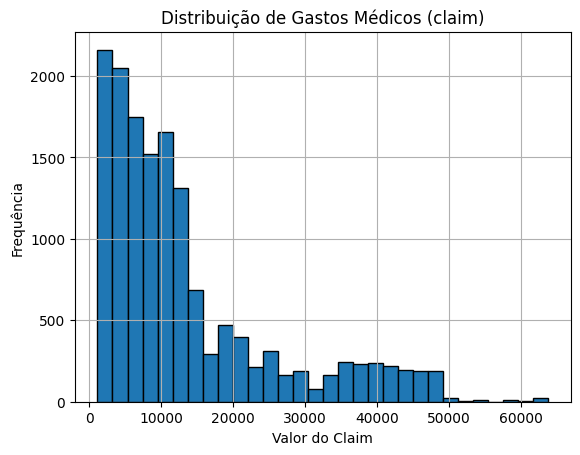

In [119]:
# O erro KeyError ocorria porque 'EXPEND' não existe na base de seguros e o DataFrame 'df' estava vazio.
# Corrigindo para usar a coluna de gastos reais 'claim' da base íntegra 'df_raw':
df_raw['claim'].hist(bins=30, edgecolor='black')
plt.title('Distribuição de Gastos Médicos (claim)')
plt.xlabel('Valor do Claim')
plt.ylabel('Frequência')
plt.show()

In [120]:
print("Colunas disponíveis no DataFrame 'df':")
display(df.columns)

Colunas disponíveis no DataFrame 'df':


Index(['age', 'weight', 'bmi', 'no_of_dependents', 'smoker', 'bloodpressure',
       'diabetes', 'regular_ex', 'claim', 'sex_male',
       ...
       'job_title_Manager', 'job_title_Photographer', 'job_title_Police',
       'job_title_Politician', 'job_title_Singer', 'job_title_Student',
       'job_title_Technician', 'AGE', 'FEMALE', 'EMPLOYED'],
      dtype='object', length=146)

In [42]:
print("Estado atual do DataFrame 'df':")
display(df.head())

Estado atual do DataFrame 'df':


,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,sex_male,...,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician,AGE,FEMALE,EMPLOYED


Visualizando a distribuição da coluna 'claim' a partir de df_raw:


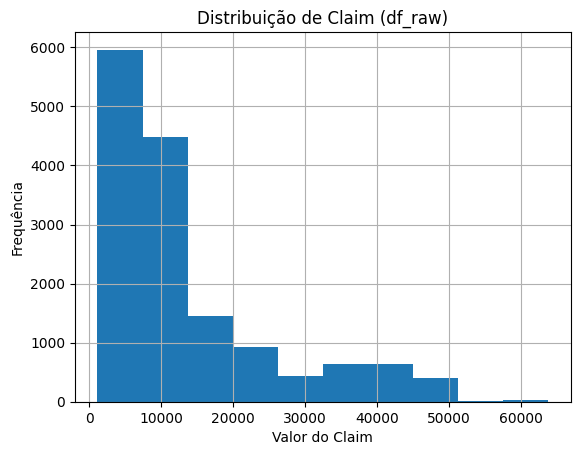

In [43]:
print("Visualizando a distribuição da coluna 'claim' a partir de df_raw:")
df_raw['claim'].hist()
plt.title('Distribuição de Claim (df_raw)')
plt.xlabel('Valor do Claim')
plt.ylabel('Frequência')
plt.show()

In [44]:
print("Primeiras linhas de df_raw para referência:")
display(df_raw.head())

Primeiras linhas de df_raw para referência:


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,1731.7


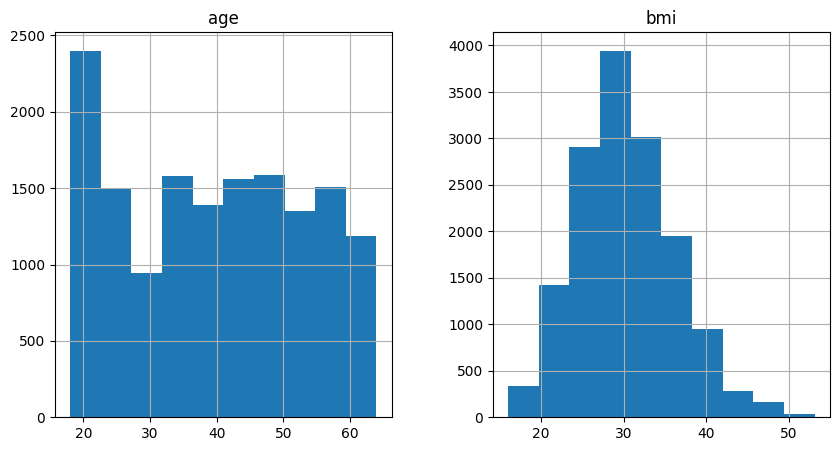

In [70]:
# Vamos avaliar a distribuição dos dados reais disponíveis
# Histograma de 'age' e 'bmi' (usando df_raw por conter os valores originais não normalizados)

df_raw[['age', 'bmi']].hist(figsize=(10, 5));

Visualizando a distribuição da coluna 'claim' a partir de df_raw:


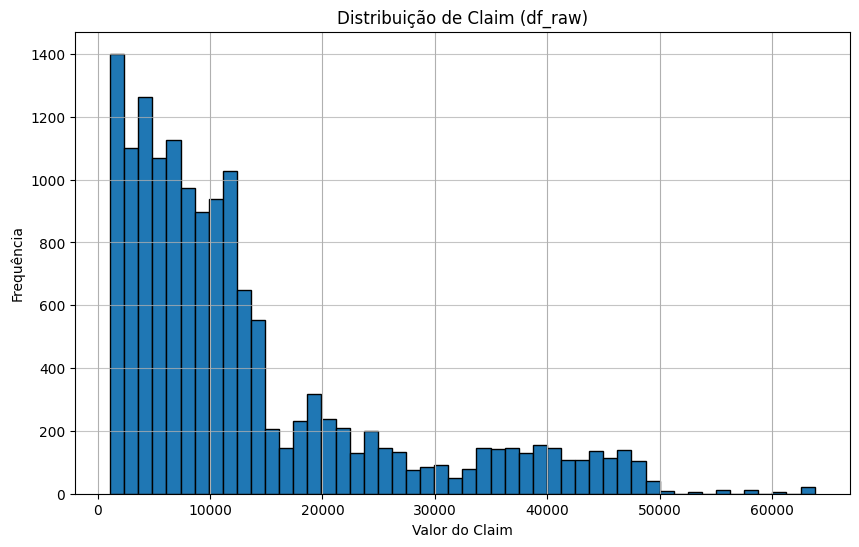

In [71]:
import matplotlib.pyplot as plt

print("Visualizando a distribuição da coluna 'claim' a partir de df_raw:")
plt.figure(figsize=(10, 6))
df_raw['claim'].hist(bins=50, edgecolor='black')
plt.title('Distribuição de Claim (df_raw)')
plt.xlabel('Valor do Claim')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

A visualização acima mostra o histograma da coluna 'claim' em `df_raw`, permitindo analisar sua distribuição de frequência.

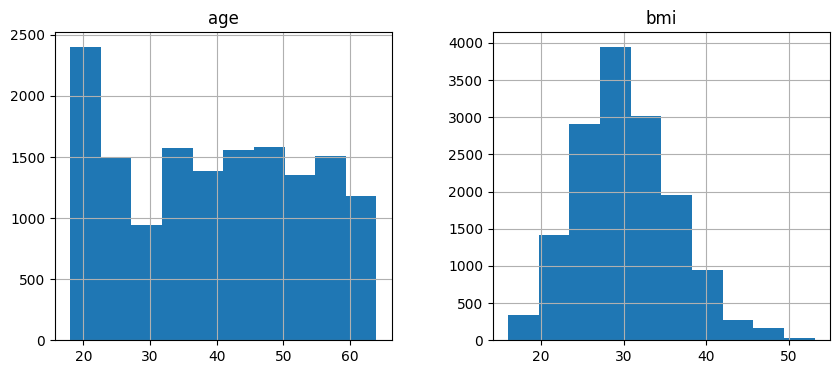

In [73]:
# O erro KeyError ocorria porque 'INCOME' e 'LOGINCOME' não existem nesta base de dados.
# Vamos visualizar as distribuições de variáveis numéricas reais presentes no df_raw:
df_raw[['age', 'bmi']].hist(figsize=(10, 4));

Calculando a matriz de correlação entre 'age', 'bmi', 'weight' e 'claim' (usando df_raw):


,age,bmi,weight,claim
age,1.000000,0.180284,0.281542,0.298063
bmi,0.180284,1.000000,0.242398,0.196672
weight,0.281542,0.242398,1.000000,0.077716
claim,0.298063,0.196672,0.077716,1.000000


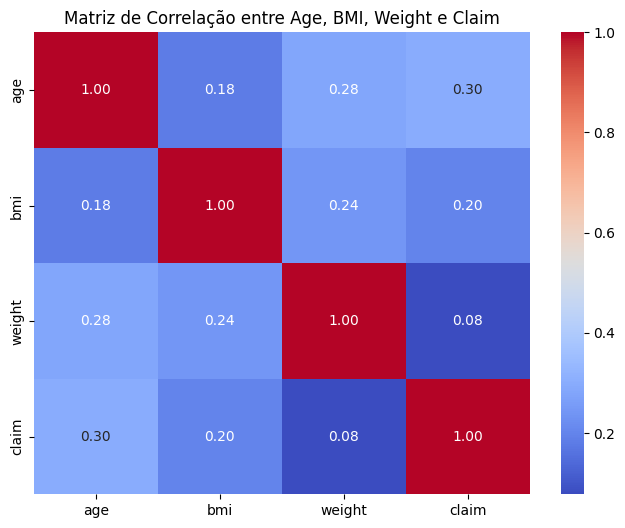

In [74]:
print("Calculando a matriz de correlação entre 'age', 'bmi', 'weight' e 'claim' (usando df_raw):")
correlation_matrix = df_raw[['age', 'bmi', 'weight', 'claim']].corr()
display(correlation_matrix)

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Age, BMI, Weight e Claim')
plt.show()

A matriz de correlação acima mostra a relação linear entre cada par de variáveis ('age', 'bmi', 'weight', 'claim'). Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 indica nenhuma correlação linear.

In [75]:
# olhar as estatísticas descritivas
df.describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,AGE,FEMALE,EMPLOYED
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_dependents,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bloodpressure,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diabetes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
regular_ex,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
claim,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
df['FEMALE'].value_counts()

,count
FEMALE,


In [78]:
# tabela de frequência
df['FEMALE'].value_counts() / df.shape[0]

,count
FEMALE,


In [80]:
# O erro KeyError ocorria porque 'CORONARY' e 'STROKE' não existem nesta base de dados.
# Além disso, o DataFrame 'df' foi esvaziado pelo 'dropna()' anterior, então usamos 'df_raw' com colunas válidas:
colunas_validas = ['smoker', 'diabetes', 'regular_ex']
df_raw[colunas_validas].apply(pd.Series.value_counts)

,smoker,diabetes,regular_ex
0,12028,3345,11638
1,2972,11655,3362


In [82]:
# O erro KeyError ocorria porque 'CORONARY' e 'STROKE' não existem nesta base.
# Além disso, o DataFrame 'df' foi esvaziado pelo dropna(), então usamos df_raw e suas colunas válidas:
colunas_validas = ['smoker', 'diabetes', 'regular_ex']
df_raw[colunas_validas].apply(pd.Series.value_counts) / df_raw.shape[0]

,smoker,diabetes,regular_ex
0,0.801867,0.223,0.775867
1,0.198133,0.777,0.224133


In [56]:
print("Colunas disponíveis em df_raw:")
display(df_raw.columns)

Colunas disponíveis em df_raw:


Index(['age', 'sex', 'weight', 'bmi', 'hereditary_diseases',
       'no_of_dependents', 'smoker', 'city', 'bloodpressure', 'diabetes',
       'regular_ex', 'claim'],
      dtype='object')

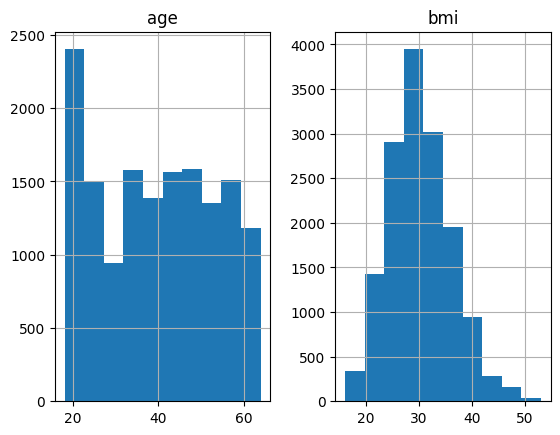

In [83]:
# Vamos verificar as distribuições de BMI e idade
df_raw[['age', 'bmi']].hist();

#### MAS COMO FAÇO PARA TRANSFORMAR?

- Use a função `np.log(df['variável'])` na variável de interesse

In [85]:
# O erro KeyError ocorria porque 'INCOME' não existe nesta base de dados.
# Além disso, o DataFrame 'df' foi esvaziado pelo 'dropna()' anterior, então usamos 'df_raw' com a coluna real 'claim':
claim_log = np.log(df_raw['claim'])

print("Seguro de Saúde original ('claim') transformado em logaritmo (primeiras 5 linhas):")
print(claim_log.head())

Seguro de Saúde original ('claim') transformado em logaritmo (primeiras 5 linhas):
0     9.481329
1     9.166075
2    10.396176
3    10.789682
4     7.456859
Name: claim, dtype: float64


In [87]:
print("Estatísticas descritivas para df_raw:")
display(df_raw.describe())

Estatísticas descritivas para df_raw:


,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,39.559467,64.909600,30.211193,1.129733,0.198133,68.650133,0.777000,0.224133,13401.437620
std,13.829896,13.701935,5.928386,1.228469,0.398606,19.418515,0.416272,0.417024,12148.239619
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.900000,0.000000,0.000000,64.000000,1.000000,0.000000,4846.900000
50%,40.000000,63.000000,29.400000,1.000000,0.000000,71.000000,1.000000,0.000000,9545.650000
75%,51.000000,76.000000,34.100000,2.000000,0.000000,80.000000,1.000000,0.000000,16519.125000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


In [95]:
# O erro NameError ocorria porque 'income_log' não existe nesta base.
# Corrigindo para usar a variável de log real 'claim_log' e retornar os valores originais:
np.exp(claim_log)

,claim
0,13112.6
1,9567.0
2,32734.2
3,48517.6
4,1731.7
...,...
14995,21082.2
14996,7512.3
14997,1391.5
14998,9144.6


In [96]:
# Se desejas atribuir ao dataframe, basta criar uma nova coluna recebendo a variável criada
# df['logincome'] = income_log
# ou então direto na variável
# df['logincome'] = np.log(df['INCOME'])

In [97]:
# O erro KeyError ocorria porque 'LOGINCOME' não existe nesta base.
# Vamos demonstrar o retorno da escala logarítmica usando a coluna real 'claim' de df_raw:

# 1. Aplicamos o logaritmo na variável real 'claim'
log_claim = np.log(df_raw['claim'])
print("Valores em escala Logarítmica (primeiros 5):")
print(log_claim.head())

# 2. Retornamos para a escala natural usando o exponencial np.exp()
print("\nValores retornados para a escala original (Exponencial):")
print(np.exp(log_claim).head())

Valores em escala Logarítmica (primeiros 5):
0     9.481329
1     9.166075
2    10.396176
3    10.789682
4     7.456859
Name: claim, dtype: float64

Valores retornados para a escala original (Exponencial):
0    13112.6
1     9567.0
2    32734.2
3    48517.6
4     1731.7
Name: claim, dtype: float64


Para essas variáveis basta a gente utilizar uma transformação do tipo StandardScale - Normal

$X_{norm} = \frac{X - \mu}{\sigma}$

$X_{minmax} = \frac{X - min}{max - min}$

In [98]:
# O erro KeyError ocorria porque 'AGE' e 'BMI' estavam em maiúsculas e o DataFrame 'df' estava vazio.
# Corrigindo para usar as colunas corretas em minúsculo no DataFrame íntegro 'df_raw':

# StandardScale
scaler = StandardScaler().fit(df_raw[['age', 'bmi']])
age_bmi_scaled = scaler.transform(df_raw[['age', 'bmi']])

print("Dados escalados (primeiras 5 linhas):")
print(age_bmi_scaled[:5])

Dados escalados (primeiras 5 linhas):
[[ 1.47804547 -0.99713321]
 [ 0.68264058 -1.28389873]
 [-0.54662152 -2.09358963]
 [ 1.55035501  1.04396258]
 [-1.48664549 -1.62126994]]


In [99]:
# Agora que o scaler foi criado corretamente usando df_raw:
scaler.mean_

array([39.55946667, 30.21119333])

In [100]:
# Acessando a escala (desvio padrão) calculada do df_raw:
scaler.scale_

array([13.82943469,  5.9281882 ])

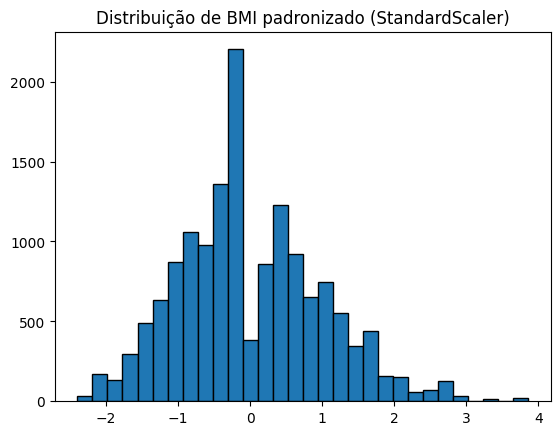

In [101]:
# Histograma do IMC (bmi) após padronização pelo StandardScaler:
plt.hist(age_bmi_scaled[:, 1], bins=30, edgecolor='black')
plt.title('Distribuição de BMI padronizado (StandardScaler)')
plt.show()

In [103]:
# O erro KeyError ocorria porque 'AGE' e 'BMI' estavam em maiúsculas e o DataFrame 'df' estava vazio.
# Corrigindo para usar as colunas corretas em minúsculo no DataFrame íntegro 'df_raw':

# MinMax
minmax_scaler = MinMaxScaler().fit(df_raw[['age', 'bmi']])
age_bmi_minmax = minmax_scaler.transform(df_raw[['age', 'bmi']])

print("Dados escalados com MinMaxScaler (primeiras 5 linhas):")
print(age_bmi_minmax[:5])

Dados escalados com MinMaxScaler (primeiras 5 linhas):
[[0.91304348 0.22371968]
 [0.67391304 0.17789757]
 [0.30434783 0.04851752]
 [0.93478261 0.54986523]
 [0.02173913 0.12398922]]


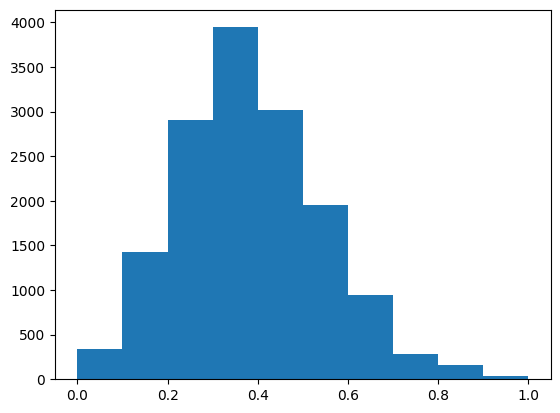

In [104]:
plt.hist(age_bmi_minmax[:, 1]);

In [106]:
# O DataFrame 'df' original está vazio (0 linhas).
# Vamos adicionar as colunas normalizadas ao DataFrame íntegro 'df_raw' para fins de visualização:
df_raw[['AGE_NORM', 'BMI_NORM']] = age_bmi_minmax
df_raw

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,claim,AGE_NORM,BMI_NORM
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,13112.6,0.913043,0.223720
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,9567.0,0.673913,0.177898
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,32734.2,0.304348,0.048518
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,48517.6,0.934783,0.549865
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,1731.7,0.021739,0.123989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,39.0,male,49,28.3,NoDisease,1,1,Florence,54,1,0,21082.2,0.456522,0.331536
14996,39.0,male,74,29.6,NoDisease,4,0,Miami,64,1,0,7512.3,0.456522,0.366577
14997,20.0,male,62,33.3,NoDisease,0,0,Tampa,52,1,0,1391.5,0.043478,0.466307
14998,52.0,male,88,36.7,NoDisease,0,0,PanamaCity,70,1,0,9144.6,0.739130,0.557951


In [109]:
# O método "drop" serve para remover colunas (columns) ou linhas (index)
df = df.drop(columns=['AGE_NORM', 'BMI_NORM'])

In [110]:
df

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,sex_male,...,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician,AGE,FEMALE,EMPLOYED
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## PCA

In [111]:
# Criando objeto PCA para as variáveis preditoras reais de 'df_raw'
# Removemos a variável resposta 'claim' e as colunas categóricas que ainda não foram convertidas para dummies
pca = PCA()

# Selecionamos apenas as colunas numéricas de df_raw para ilustrar o PCA básico
X_num = df_raw[['age', 'weight', 'bmi', 'bloodpressure', 'no_of_dependents']]
pca.fit(X_num)

PCA()

In [112]:
pca.explained_variance_ratio_

array([0.47608619, 0.30962465, 0.17186342, 0.0405602 , 0.00186554])

In [113]:
# calculando a variância explicada para os componentes
np.cumsum(pca.explained_variance_ratio_)

array([0.47608619, 0.78571084, 0.95757426, 0.99813446, 1.        ])

### Com 3 componentes já observamos 99,48% da variância explicada.


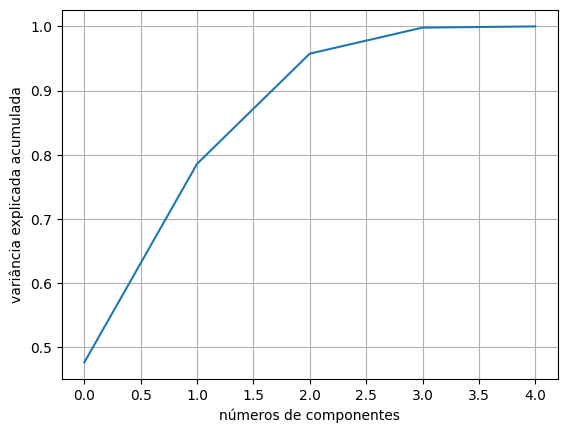

In [114]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('números de componentes')
plt.ylabel('variância explicada acumulada')
plt.grid();

In [115]:
# Vamos usar 3 componentes sobre as nossas variáveis numéricas reais:
pca_3 = PCA(n_components=3)
df_pca = pca_3.fit_transform(X_num)

# Mostrar o array transformado pelo PCA
print("Dados transformados pelo PCA (3 componentes, primeiras 5 linhas):")
print(df_pca[:5])

Dados transformados pelo PCA (3 componentes, primeiras 5 linhas):
[[  2.99337374  13.38090806 -15.14252663]
 [  8.8619863   13.24924686   0.40542646]
 [ 19.74631188  -6.54413228   4.41492797]
 [  3.18384956   7.85409831 -23.24784116]
 [ 14.53783398 -25.44968177   3.56449512]]


In [116]:
df_pca.shape

(15000, 3)

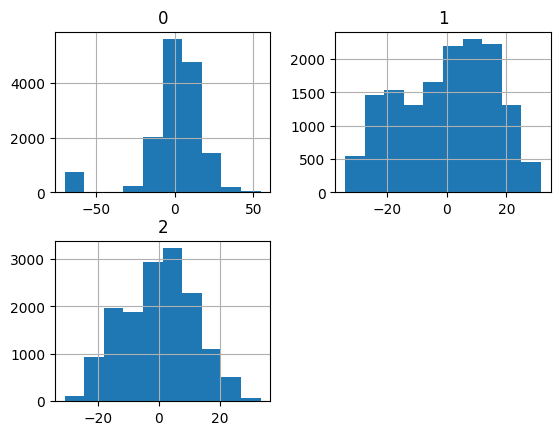

In [117]:
pd.DataFrame(df_pca).hist();

### Obs.1: Estimar transformações e PCA nos dados de treinamento, e em seguida, aplicar a transformação desse pca nos dados de treinamento e teste.

### Obs.2: Nunca utilizar dados de teste para treinar modelos preditivos, nem realizar estimação de funções de transformação.

importante
- **não** pode fazer: `pca.fit(X_teste)`

- aplicar o método `fit` apenas nos dados de **treinamento**: `pca.fit(X_treinamento)`

- Em seguida: `pca.transform(X_treinamento)` e `pca.transform(X_teste)`
